# Basic Statistical Tests for `combined_general_agg.csv`

Этот ноутбук делает базовый, практичный статистический анализ для SFQ-данных (Likert 1-5 + NPS 0-10):

1. Описательные статистики по ключевым метрикам
2. Средние с bootstrap 95% CI (в целом и по программам)
3. Сравнение программ по `nps`: ANOVA + проверка предпосылок
4. Устойчивый непараметрический тест: Kruskal-Wallis + Dunn post-hoc
5. Матрица корреляций Spearman
6. Базовая OLS-регрессия для предикторов `nps` (robust SE)

Визуализации оформлены в стиле `ggplot`.


In [1]:
import os
from pathlib import Path

# Avoid matplotlib cache issues in restricted environments
Path('.mplconfig').mkdir(exist_ok=True)
os.environ['MPLCONFIGDIR'] = str(Path('.mplconfig').resolve())

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
import scikit_posthocs as sp
import statsmodels.api as sm
from statsmodels.formula.api import ols

plt.style.use('ggplot')
sns.set_theme(style='whitegrid', context='talk')

pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', lambda x: f'{x:0.3f}')


In [2]:
df = pd.read_csv('combined_general_agg.csv')
print('Shape:', df.shape)
print('Programs:', df['program'].nunique())

program_counts = df['program'].value_counts().rename('n')
program_counts.to_frame().head(18)


Shape: (236, 72)
Programs: 18


,n
program,
Кинопроизводство,58
Архитектура и градостроительство,40
Foundation Art and Design,31
Дизайн одежды и текстиля,25
Проектирование зданий и городских общественных пространств,14
Дизайн и архитектура интерьера,11
Бренд-менеджмент и маркетинг в креативных индустриях,10
Современное искусство,10
Иллюстрация,8


## 1) Базовая структура выборки

Сначала фиксируем распределение `n` по программам, чтобы корректно трактовать инференциальные тесты.


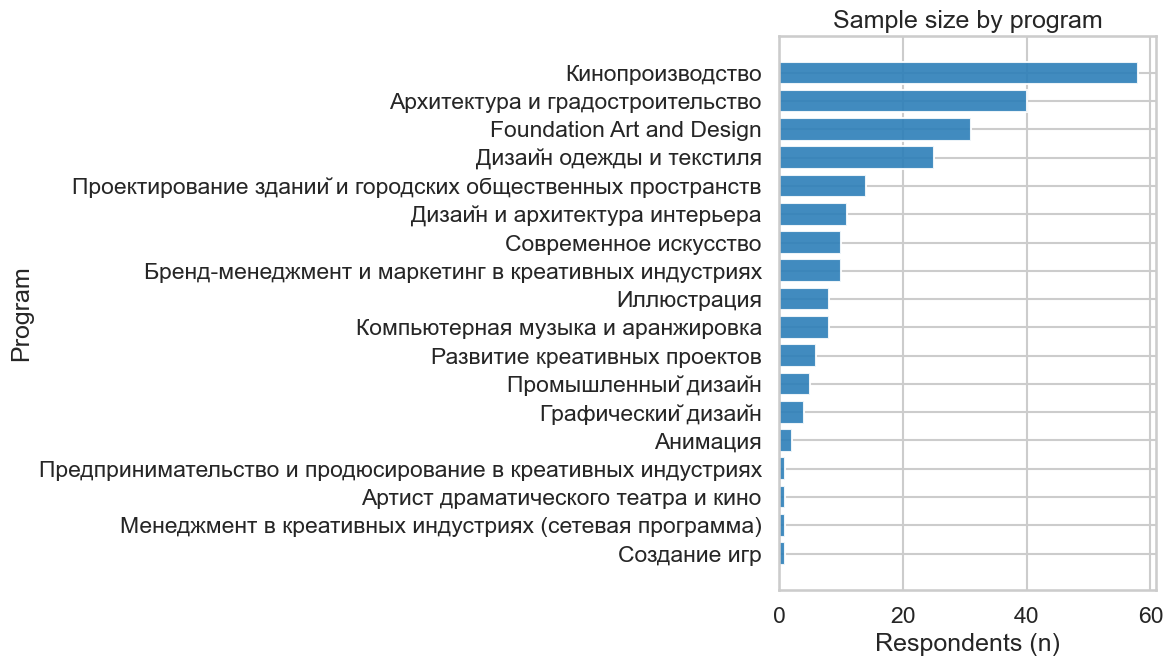

Минимальный размер группы: 1
Количество групп с n < 5: 6


In [3]:
fig, ax = plt.subplots(figsize=(12, 7))
order = program_counts.sort_values(ascending=True)
ax.barh(order.index, order.values, color='#2C7FB8', alpha=0.9)
ax.set_title('Sample size by program')
ax.set_xlabel('Respondents (n)')
ax.set_ylabel('Program')
plt.tight_layout()
plt.show()

print('Минимальный размер группы:', int(program_counts.min()))
print('Количество групп с n < 5:', int((program_counts < 5).sum()))


## 2) Описательные статистики и bootstrap CI

Для Likert-данных и неравных групп используем средние + bootstrap 95% CI.


In [4]:
def bootstrap_mean_ci(x, n_boot=5000, ci=95, seed=42):
    x = pd.Series(x).dropna().astype(float).to_numpy()
    if x.size == 0:
        return np.nan, np.nan, np.nan, 0
    rng = np.random.default_rng(seed)
    samples = rng.choice(x, size=(n_boot, x.size), replace=True)
    means = samples.mean(axis=1)
    alpha = (100 - ci) / 2
    return x.mean(), np.percentile(means, alpha), np.percentile(means, 100 - alpha), x.size

key_metrics = [
    'satisf_overall', 'satisf_teachers', 'expect_match',
    'assess_criteria_timely', 'assess_order_clear', 'assess_consistent',
    'nps'
]
key_metrics = [c for c in key_metrics if c in df.columns]

rows = []
for col in key_metrics:
    mean_, lwr, upr, n = bootstrap_mean_ci(df[col])
    rows.append({'metric': col, 'n': n, 'mean': mean_, 'ci_low': lwr, 'ci_high': upr, 'std': df[col].std()})

desc_overall = pd.DataFrame(rows).sort_values('metric')
desc_overall


,metric,n,mean,ci_low,ci_high,std
5,assess_consistent,236,3.394,3.284,3.504,0.876
3,assess_criteria_timely,236,3.284,3.161,3.403,0.941
4,assess_order_clear,236,3.301,3.182,3.415,0.926
2,expect_match,77,2.831,2.597,3.052,1.005
6,nps,236,7.153,6.826,7.475,2.534
0,satisf_overall,236,2.915,2.822,3.013,0.745
1,satisf_teachers,226,3.115,3.018,3.212,0.757


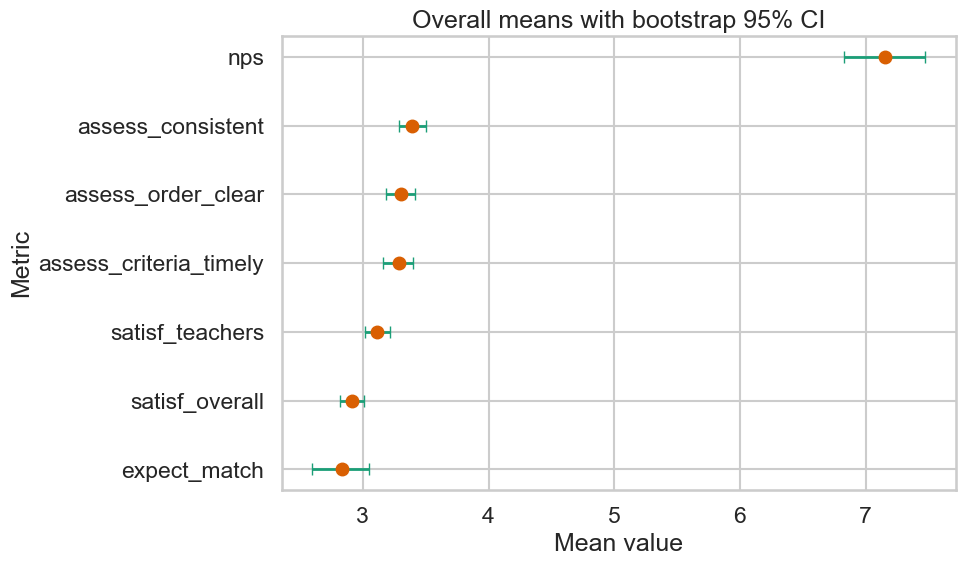

In [5]:
plot_df = desc_overall.sort_values('mean')
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(
    plot_df['mean'], plot_df['metric'],
    xerr=[plot_df['mean'] - plot_df['ci_low'], plot_df['ci_high'] - plot_df['mean']],
    fmt='o', color='#D95F02', ecolor='#1B9E77', elinewidth=2, capsize=4
)
ax.set_title('Overall means with bootstrap 95% CI')
ax.set_xlabel('Mean value')
ax.set_ylabel('Metric')
plt.tight_layout()
plt.show()


### `nps` по программам: среднее + bootstrap 95% CI

In [6]:
rows = []
for prog, g in df.groupby('program'):
    mean_, lwr, upr, n = bootstrap_mean_ci(g['nps'])
    rows.append({'program': prog, 'n': n, 'mean_nps': mean_, 'ci_low': lwr, 'ci_high': upr})

nps_by_program = pd.DataFrame(rows).sort_values('mean_nps', ascending=False)
nps_by_program.head(20)


,program,n,mean_nps,ci_low,ci_high
11,Менеджмент в креативных индустриях (сетевая пр...,1,10.000,10.000,10.000
13,Проектирование зданий и городских общественны...,14,9.071,8.429,9.643
1,Анимация,2,9.000,8.000,10.000
0,Foundation Art and Design,31,8.419,7.839,8.968
15,Развитие креативных проектов,6,8.333,7.333,9.333
3,Архитектура и градостроительство,40,8.025,7.300,8.650
12,Предпринимательство и продюсирование в креатив...,1,8.000,8.000,8.000
16,Современное искусство,10,7.700,6.900,8.600
6,Дизайн и архитектура интерьера,11,7.455,6.273,8.455
14,Промышленный дизайн,5,7.200,5.000,9.400


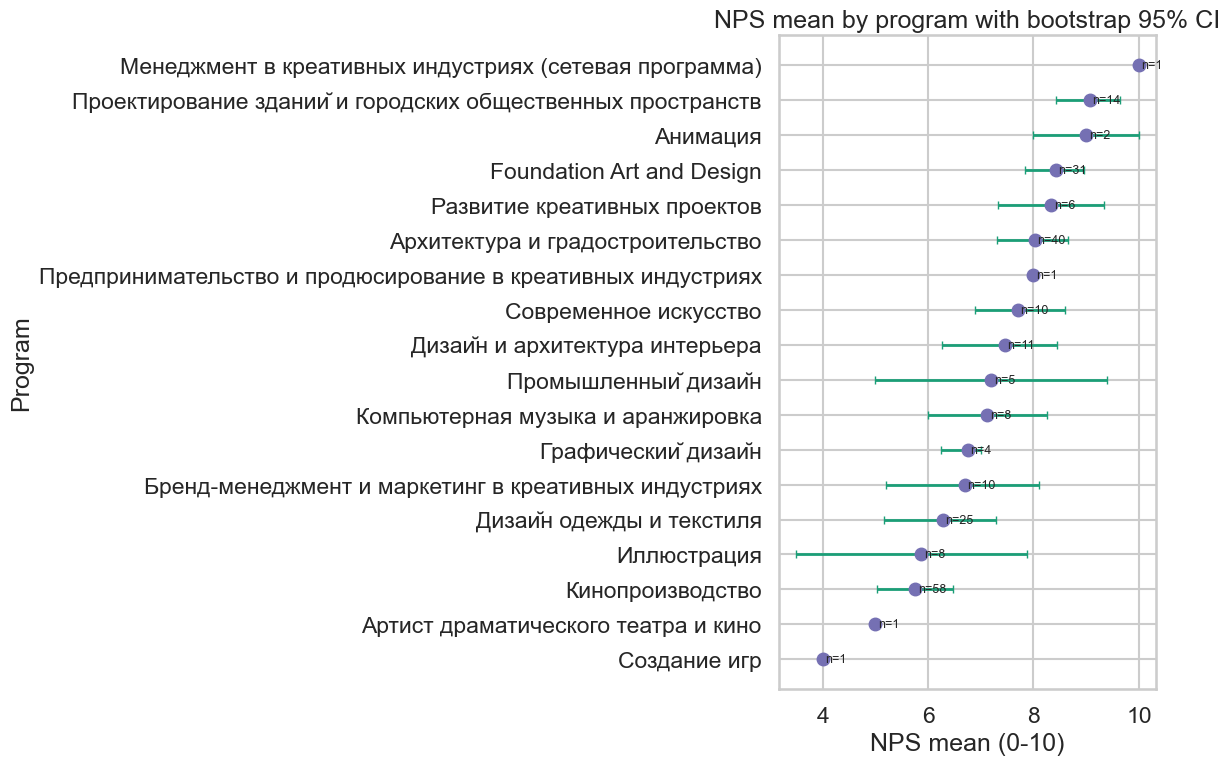

In [7]:
plot_df = nps_by_program.sort_values('mean_nps')
fig, ax = plt.subplots(figsize=(12, 8))
ax.errorbar(
    plot_df['mean_nps'], plot_df['program'],
    xerr=[plot_df['mean_nps'] - plot_df['ci_low'], plot_df['ci_high'] - plot_df['mean_nps']],
    fmt='o', color='#7570B3', ecolor='#1B9E77', elinewidth=2, capsize=3
)
for i, n in enumerate(plot_df['n']):
    ax.text(plot_df['mean_nps'].iloc[i] + 0.05, plot_df['program'].iloc[i], f'n={int(n)}', va='center', fontsize=9)

ax.set_title('NPS mean by program with bootstrap 95% CI')
ax.set_xlabel('NPS mean (0-10)')
ax.set_ylabel('Program')
plt.tight_layout()
plt.show()


## 3) Сравнение программ по `nps`: ANOVA + Kruskal-Wallis

Для честного сравнения исключаем очень маленькие группы (`n < 5`) из инференциальных тестов.


In [8]:
min_group_n = 5
valid_programs = program_counts[program_counts >= min_group_n].index
df_inf = df[df['program'].isin(valid_programs)][['program', 'nps']].dropna().copy()

print('Групп в инференциальном анализе:', df_inf['program'].nunique())
print('Наблюдений:', len(df_inf))
print('Порог min_group_n =', min_group_n)


Групп в инференциальном анализе: 12
Наблюдений: 226
Порог min_group_n = 5


In [9]:
# ANOVA
anova_model = ols('nps ~ C(program)', data=df_inf).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)

ss_between = anova_table.loc['C(program)', 'sum_sq']
ss_total = anova_table['sum_sq'].sum()
eta_sq = ss_between / ss_total

# Homogeneity of variance check (Levene)
groups = [g['nps'].values for _, g in df_inf.groupby('program')]
lev_stat, lev_p = stats.levene(*groups, center='median')

print('Levene test (median-centered): stat=%.3f, p=%.4f' % (lev_stat, lev_p))
print('ANOVA eta^2 = %.3f' % eta_sq)
anova_table


Levene test (median-centered): stat=2.298, p=0.0112
ANOVA eta^2 = 0.197


,sum_sq,df,F,PR(>F)
C(program),290.962,11.000,4.781,0.000
Residual,1183.923,214.000,NaN,NaN


In [10]:
# Kruskal-Wallis
kw_stat, kw_p = stats.kruskal(*groups)
print('Kruskal-Wallis: H=%.3f, p=%.4f' % (kw_stat, kw_p))

# Dunn post-hoc with Holm correction
pvals_dunn = sp.posthoc_dunn(df_inf, val_col='nps', group_col='program', p_adjust='holm')
pvals_dunn


Kruskal-Wallis: H=43.401, p=0.0000


,Foundation Art and Design,Архитектура и градостроительство,Бренд-менеджмент и маркетинг в креативных индустриях,Дизайн и архитектура интерьера,Дизайн одежды и текстиля,Иллюстрация,Кинопроизводство,Компьютерная музыка и аранжировка,Проектирование зданий и городских общественных пространств,Промышленный дизайн,Развитие креативных проектов,Современное искусство
Foundation Art and Design,1.000,1.000,1.000,1.000,0.148,1.000,0.001,1.000,1.000,1.000,1.000,1.000
Архитектура и градостроительство,1.000,1.000,1.000,1.000,0.376,1.000,0.001,1.000,1.000,1.000,1.000,1.000
Бренд-менеджмент и маркетинг в креативных индустриях,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.633,1.000,1.000,1.000
Дизайн и архитектура интерьера,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
Дизайн одежды и текстиля,0.148,0.376,1.000,1.000,1.000,1.000,1.000,1.000,0.030,1.000,1.000,1.000
Иллюстрация,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.330,1.000,1.000,1.000
Кинопроизводство,0.001,0.001,1.000,1.000,1.000,1.000,1.000,1.000,0.000,1.000,1.000,1.000
Компьютерная музыка и аранжировка,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
Проектирование зданий и городских общественных пространств,1.000,1.000,0.633,1.000,0.030,0.330,0.000,1.000,1.000,1.000,1.000,1.000
Промышленный дизайн,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


## 4) Корреляции: Spearman матрица

Для порядковых шкал 1-5 предпочтительна корреляция Spearman.


In [11]:
candidate_cols = [
    'satisf_overall', 'satisf_teachers', 'expect_match',
    'fac_support_score', 'fac_clarity_score',
    'cur_timely_score', 'cur_help_score',
    'prog_clarity_score', 'prog_deadlines_score', 'prog_relevance_score', 'prog_workload_score',
    'coord_respect_score', 'coord_results_score', 'coord_timely_score', 'coord_help_score',
    'assess_criteria_timely', 'assess_order_clear', 'assess_consistent',
    'infra_library', 'infra_wellbeing', 'infra_food', 'infra_software', 'infra_equipment', 'infra_classrooms', 'infra_workshops',
    'nps'
]

corr_cols = [c for c in candidate_cols if c in df.columns]

# Remove columns with too many missings to keep matrix stable
corr_data = df[corr_cols].copy()
min_non_null = int(0.6 * len(df))
usable_cols = [c for c in corr_data.columns if corr_data[c].notna().sum() >= min_non_null]
corr_data = corr_data[usable_cols]

corr_s = corr_data.corr(method='spearman')
corr_s.head()


,satisf_overall,satisf_teachers,fac_support_score,fac_clarity_score,cur_timely_score,cur_help_score,prog_clarity_score,prog_deadlines_score,prog_relevance_score,prog_workload_score,coord_respect_score,coord_results_score,coord_timely_score,coord_help_score,assess_criteria_timely,assess_order_clear,assess_consistent,infra_library,infra_wellbeing,infra_food,infra_software,infra_equipment,infra_classrooms,infra_workshops,nps
satisf_overall,1.000,0.596,0.493,0.354,0.371,0.364,0.477,0.219,0.485,0.440,0.313,0.303,0.436,0.313,0.410,0.462,0.412,0.150,0.204,0.159,0.180,0.209,0.290,0.340,0.601
satisf_teachers,0.596,1.000,0.693,0.575,0.347,0.321,0.426,0.297,0.372,0.325,0.243,0.225,0.268,0.238,0.425,0.550,0.456,0.249,0.093,0.137,0.166,0.192,0.253,0.299,0.491
fac_support_score,0.493,0.693,1.000,0.526,0.372,0.398,0.415,0.287,0.339,0.302,0.201,0.208,0.235,0.200,0.413,0.545,0.447,0.284,0.160,0.128,0.223,0.230,0.285,0.249,0.499
fac_clarity_score,0.354,0.575,0.526,1.000,0.329,0.380,0.391,0.363,0.290,0.239,0.191,0.161,0.185,0.177,0.348,0.408,0.467,0.225,0.159,0.091,0.130,0.128,0.225,0.196,0.361
cur_timely_score,0.371,0.347,0.372,0.329,1.000,0.654,0.227,0.116,0.267,0.334,0.307,0.369,0.489,0.344,0.336,0.322,0.288,0.237,0.221,0.161,0.240,0.296,0.179,0.187,0.245


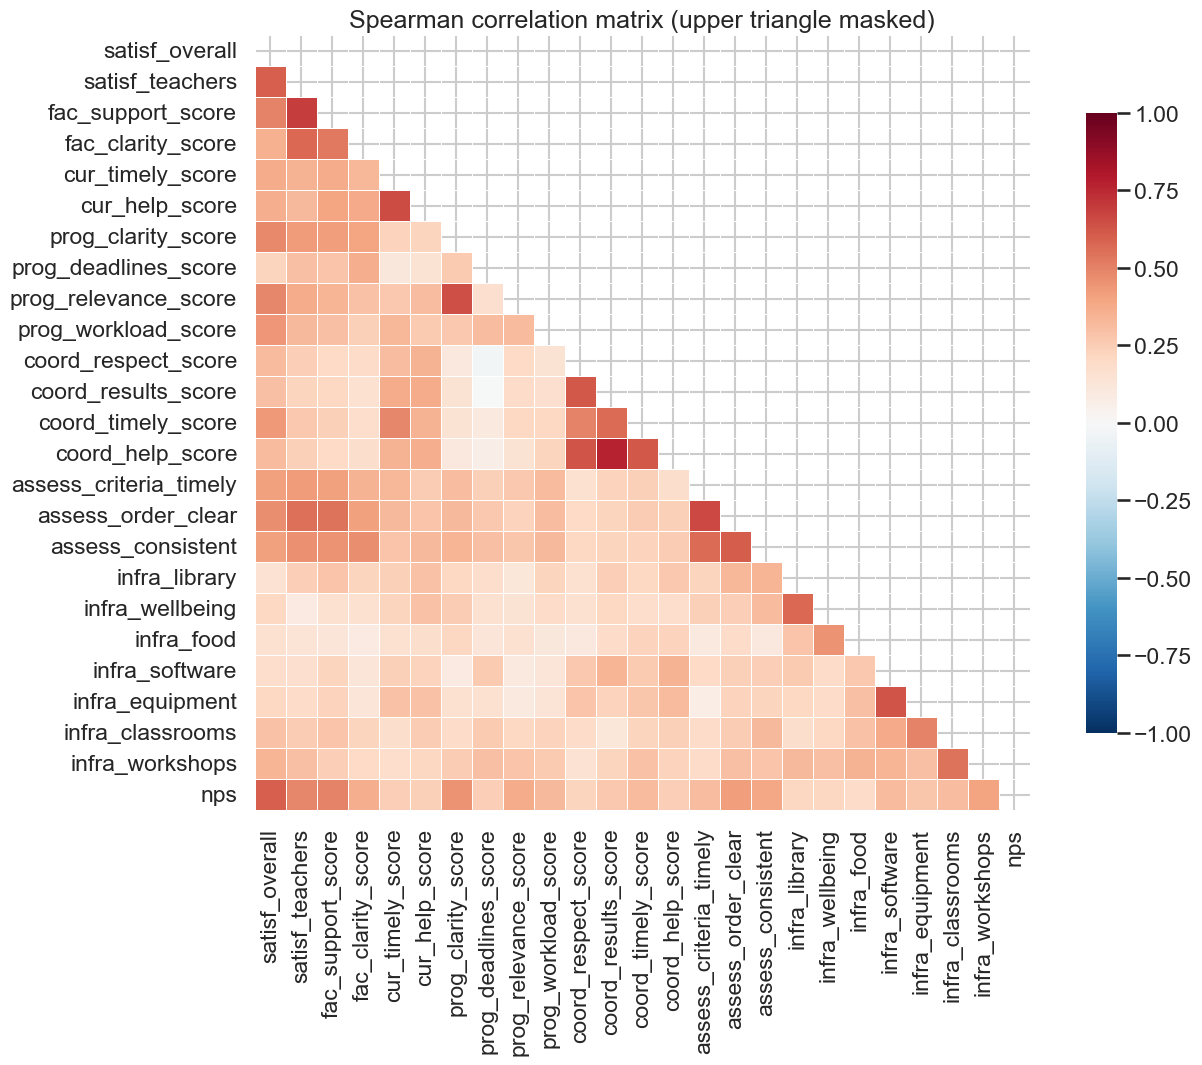

In [12]:
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_s, dtype=bool))
sns.heatmap(
    corr_s, mask=mask, cmap='RdBu_r', vmin=-1, vmax=1, center=0,
    square=True, linewidths=.5, cbar_kws={'shrink': .8}, ax=ax
)
ax.set_title('Spearman correlation matrix (upper triangle masked)')
plt.tight_layout()
plt.show()


## 5) Базовая регрессия: что связано с `nps`

Строим простую OLS с robust SE (HC3). Для уменьшения мультиколлинеарности используем агрегаты блоков вопросов.


In [13]:
df_reg = df.copy()

# Block-level composites
df_reg['fac_score_mean'] = df_reg[['fac_support_score', 'fac_clarity_score']].mean(axis=1)
df_reg['cur_score_mean'] = df_reg[['cur_timely_score', 'cur_help_score']].mean(axis=1)
df_reg['prog_score_mean'] = df_reg[['prog_clarity_score', 'prog_deadlines_score', 'prog_relevance_score', 'prog_workload_score']].mean(axis=1)
df_reg['coord_score_mean'] = df_reg[['coord_respect_score', 'coord_results_score', 'coord_timely_score', 'coord_help_score']].mean(axis=1)
df_reg['assess_score_mean'] = df_reg[['assess_criteria_timely', 'assess_order_clear', 'assess_consistent']].mean(axis=1)
df_reg['infra_score_mean'] = df_reg[['infra_library', 'infra_wellbeing', 'infra_food', 'infra_software', 'infra_equipment', 'infra_classrooms', 'infra_workshops']].mean(axis=1)

predictors = [
    'satisf_overall', 'expect_match',
    'fac_score_mean', 'cur_score_mean', 'prog_score_mean',
    'coord_score_mean', 'assess_score_mean', 'infra_score_mean'
]

model_df = df_reg[['nps'] + predictors].dropna().copy()
print('Regression sample size:', len(model_df))

X = sm.add_constant(model_df[predictors])
y = model_df['nps']

ols_model = sm.OLS(y, X).fit(cov_type='HC3')
print(ols_model.summary())


Regression sample size: 77
                            OLS Regression Results                            
Dep. Variable:                    nps   R-squared:                       0.509
Model:                            OLS   Adj. R-squared:                  0.451
Method:                 Least Squares   F-statistic:                     7.479
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           4.20e-07
Time:                        22:31:34   Log-Likelihood:                -132.88
No. Observations:                  77   AIC:                             283.8
Df Residuals:                      68   BIC:                             304.9
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const      

In [14]:
coef_df = pd.DataFrame({
    'term': ols_model.params.index,
    'coef': ols_model.params.values,
    'p_value': ols_model.pvalues.values
})
ci = ols_model.conf_int()
coef_df['ci_low'] = ci[0].values
coef_df['ci_high'] = ci[1].values
coef_df = coef_df[coef_df['term'] != 'const'].sort_values('coef')
coef_df


,term,coef,p_value,ci_low,ci_high
7,assess_score_mean,-0.449,0.381,-1.452,0.555
4,cur_score_mean,-0.182,0.583,-0.832,0.468
3,fac_score_mean,-0.050,0.913,-0.946,0.846
1,satisf_overall,0.016,0.974,-0.935,0.966
8,infra_score_mean,0.325,0.535,-0.702,1.352
2,expect_match,0.586,0.106,-0.125,1.297
6,coord_score_mean,0.640,0.119,-0.165,1.444
5,prog_score_mean,1.161,0.008,0.307,2.015


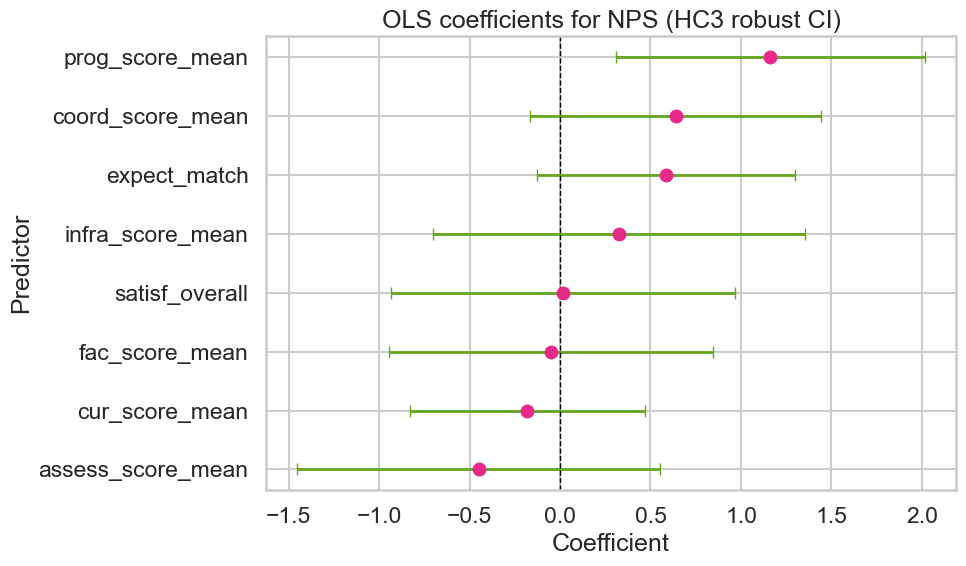

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(
    coef_df['coef'], coef_df['term'],
    xerr=[coef_df['coef'] - coef_df['ci_low'], coef_df['ci_high'] - coef_df['coef']],
    fmt='o', color='#E7298A', ecolor='#66A61E', elinewidth=2, capsize=4
)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('OLS coefficients for NPS (HC3 robust CI)')
ax.set_xlabel('Coefficient')
ax.set_ylabel('Predictor')
plt.tight_layout()
plt.show()


## 6) Интерпретация и выбор метода

Рекомендуемый базовый пайплайн для ваших данных:

1. **Описательные статистики + bootstrap CI** по ключевым метрикам (обязательно)
2. **Spearman корреляции** (обязательно)
3. **Kruskal-Wallis + Dunn** для сравнения программ (предпочтительно)
4. **ANOVA** как дополнительный референс (с проверкой предпосылок)
5. **OLS с robust SE** для факторного анализа `nps` (базовый уровень)

### Нужно ли «байесовское среднее»?

- Для текущего объема (`n=236`) и прикладной задачи: обычно **не обязательно**.
- Практичный компромисс: bootstrap CI уже дает стабильные интервальные оценки без сильных предположений.
- Если нужен Bayesian слой, лучше добавить отдельно и точечно (например, для очень малых программ с частичным pooling), а не как обязательный этап этого базового отчета.
